In [7]:
# !pip install nltk

In [8]:
sent  = "How come one man goes through life crossing one hurdle after another, accomplishing his goals while another struggles and gets nowhere ?"
print(sent)

How come one man goes through life crossing one hurdle after another, accomplishing his goals while another struggles and gets nowhere ?


## Text Preprocessing

Text preprocessing is an essential step in natural language processing (NLP) tasks. It involves transforming raw text data into a format that is more suitable for analysis and machine learning algorithms. In this tutorial, we will cover various common techniques for text preprocessing. Let's dive in!


### Lowercasing
Converting all text to lowercase can help to normalize the data and reduce the vocabulary size. It ensures that words in different cases are treated as the same word. For example, "apple" and "Apple" will both be transformed to "apple".

In [9]:
lower_sent  = sent.lower()

lower_sent

'how come one man goes through life crossing one hurdle after another, accomplishing his goals while another struggles and gets nowhere ?'

### Removal of Punctuation and Special Characters
Punctuation marks and special characters often do not add much meaning to the text and can be safely removed. Common punctuation marks include periods, commas, question marks, and exclamation marks. You can use regular expressions or string operations to remove them.

In [10]:
import re

cleaned = re.sub(r"[^\w\s]" , "", lower_sent)
cleaned

'how come one man goes through life crossing one hurdle after another accomplishing his goals while another struggles and gets nowhere '

### Stop Word Removal:
Stop words are commonly occurring words in a language, such as "a," "an," "the," "is," and "in." These words provide little semantic value and can be removed to reduce noise in the data. Libraries like NLTK provide a list of predefined stop words for different languages.

Before using the code make sure you downloaded all the stopwords uning the first shell below.

In [11]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/suko-
[nltk_data]     magar/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
from nltk.corpus import stopwords
stopwords_eng = stopwords.words("english")
print(stopwords_eng)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [13]:
res = [ word for word in cleaned.split(" ") if word not in stopwords_eng]
cleaned_text = " ".join(res)
cleaned_text

'come one man goes life crossing one hurdle another accomplishing goals another struggles gets nowhere '

## Tokenization

Tokenization is the process of breaking down a piece of text into smaller units called tokens. These tokens can be words, subwords, or even characters, depending on the level of granularity desired. Tokenization is a fundamental step in text preprocessing and is crucial for various natural language processing (NLP) tasks, such as machine translation, sentiment analysis, and language generation.

### Word Tokenization

Word tokenization is the most common form of tokenization, where the text is split into individual words. For example, given the sentence "Tokenization is important for NLP tasks," the word tokens would be: ["Tokenization", "is", "important", "for", "NLP", "tasks"].

Word tokenization is typically performed using whitespace as the delimiter. However, it's important to handle cases like punctuation marks, contractions, and hyphenated words correctly. For example, "don't" should be tokenized as ["do", "n't"] instead of ["don", "'", "t"].

Libraries like NLTK, spaCy, and the tokenizers package provide ready-to-use word tokenization functions.


Before running any of these tokenization techniques, make sure you have `punkt` downloaded. `punkt` refers to the Punkt Tokenizer, which is a pre-trained unsupervised machine learning model for sentence tokenization. The NLTK Punkt Tokenizer is trained on large corpora and is capable of handling a wide range of sentence boundary detection for multiple languages. It uses a combination of rule-based heuristics and statistical models to identify sentence boundaries accurately.

In [14]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /home/suko-magar/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/suko-
[nltk_data]     magar/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
tokens = nltk.wordpunct_tokenize(cleaned_text)
tokens

['come',
 'one',
 'man',
 'goes',
 'life',
 'crossing',
 'one',
 'hurdle',
 'another',
 'accomplishing',
 'goals',
 'another',
 'struggles',
 'gets',
 'nowhere']

## Stemming and Lemmatization

Stemming and lemmatization are techniques used in natural language processing (NLP) to reduce words to their base or root forms. Both approaches aim to normalize words and reduce inflectional variations, enabling better analysis and comparison of words. However, they differ in their methods and outputs. Let's dive into each technique in detail:

### Stemming

Stemming is a process of reducing words to their base or root forms by removing prefixes or suffixes. The resulting form is often a stem, which may not be an actual word itself. The primary goal of stemming is to simplify the vocabulary and group together words with the same base meaning.

For example, when using a stemming algorithm on the words "running," "runs," and "ran," the common stem would be "run." The stemming process cuts off the suffixes ("-ning," "-s," and "-"), leaving behind the core form of the word.

Stemming algorithms follow simple rules and heuristics based on linguistic patterns, rather than considering the context or part of speech of the word. Some popular stemming algorithms include the Porter stemming algorithm, the Snowball stemmer (which supports multiple languages), and the Lancaster stemming algorithm.

Stemming is a computationally lightweight approach and can be useful in certain cases where the exact word form is not crucial. However, it may produce stems that are not actual words, leading to potential loss of meaning and ambiguity.

In [16]:
from nltk.stem import LancasterStemmer, PorterStemmer

In [17]:
stemmer = LancasterStemmer()

stemmer.stem("tastier")

'tasty'

### Lemmatization

Lemmatization, on the other hand, aims to reduce words to their canonical or dictionary forms, known as lemmas. Unlike stemming, lemmatization considers the context and part of speech (POS) of the word to generate meaningful lemmas. The resulting lemmas are actual words found in the language's dictionary.

For example, when lemmatizing the words "running," "runs," and "ran," the lemma for each would be "run." Lemmatization takes into account the POS information to accurately determine the base form of the word.

Lemmatization algorithms use linguistic rules and morphological analysis to identify the appropriate lemma. They often rely on language-specific resources, such as word lists and morphological databases. Some popular lemmatization tools include the WordNet lemmatizer and the spaCy library (which supports lemmatization for multiple languages).

Lemmatization typically produces more accurate and meaningful results compared to stemming because it retains the core meaning of words. It is especially useful in tasks that require precise word analysis, such as information retrieval, question answering, and sentiment analysis.

However, lemmatization can be more computationally intensive compared to stemming due to its reliance on POS tagging and language-specific resources.

Before running any of these tokenization techniques, make sure you have `wordnet` downloaded.

In [18]:
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to /home/suko-
[nltk_data]     magar/nltk_data...


True

In [19]:
from nltk.stem import WordNetLemmatizer

In [20]:
lemmatizer = WordNetLemmatizer()
lemmatizer.lemmatize("running")

'running'

In [21]:
lemmatizer.lemmatize("cats")

'cat'

When deciding between stemming and lemmatization, consider the trade-off between simplicity and accuracy. If you require speed and a broad reduction of word forms, stemming may be sufficient. However, if you need more accurate analysis and want to preserve the semantic meaning of words, lemmatization is generally the preferred choice.

It's important to note that both stemming and lemmatization have limitations. They may not always produce the correct base forms, especially for irregular words or those not present in the chosen language's dictionary. Contextual information, such as word sense disambiguation, can further enhance the accuracy of both techniques.

In [22]:
lemma_tokens = [ lemmatizer.lemmatize(token) for token in tokens]
lemma_tokens

['come',
 'one',
 'man',
 'go',
 'life',
 'crossing',
 'one',
 'hurdle',
 'another',
 'accomplishing',
 'goal',
 'another',
 'struggle',
 'get',
 'nowhere']

## Word Embedding

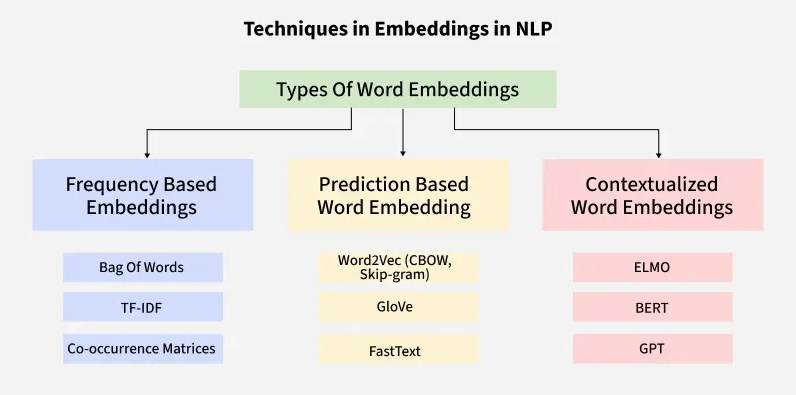

# Frequency Based Embeddings

### Bag of words (BoW)

**Bag of Words** model is the simplest and most popular form of word embedding. The key idea of **BoW** models is to encode every word in the vocabulary as one-hot-encoded vector.

If r1, r2 and r3 be three records, the vectors corresponding to r1, r2 and r3 be v1, v2 and v3 respectively such that r1 and r2 are more similar to each other as compared to r3. Then, as general understanding, the vector distance between v1 and v2 is less than that between v1 and v3 or v2 and v3.

<p align="center"><b>
    distance (v1, v2) < distance (v1, v3)<br/>
    similarity (r1, r2) > similarity (r1, r3)
</b></p>

For easy understanding, let us consider a sweet example. Let there be three reviews for a product in ecommerce site as:

    r1: This product is good and is affordable.
    r2: This product is not good and affordable.
    r3: This product is good and cheap.

Let's see how BoW encodes the text data to machine compatible form. Follow along with the below points:

**I. Construct a set of all the unique words present in the corpus:**

    { this, product, is, good, and, affordable, not, cheap }

There are a total of 8 uique words in the set formed. So the size of the vector generated for each review will be 8 as well, with the index position starting from 0 and ending to 7 i.e. 

    { 0: this, 1: product, 2: is, 3: good, 4: and, 5: affordable, 6: not, 7: cheap }

**II. Construct a d-dimensional vector for each review separately:**

Construct a d-dimensional vector (*d* being the vocabulary size) for each review. Each index/dimension of the vector corresponds to a unique word in the vocabulary. The value in each cell of the vector represents the number of times the word with that index occurs in the corpus.

 d | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
---|---|---|---|---|---|---|---|---|
**v1**| 1 | 1 | 2 | 1 | 1 | 1 | 0 | 0 |
**v2**| 1 | 1 | 1 | 1 | 1 | 1 | 1 | 0 |
**v3**| 1 | 1 | 1 | 1 | 1 | 0 | 0 | 1 |

<p style="text-align:center;"><i><b>Table :</b> 8 dimensional vector representation of each review</i></p>

#### Objective

Similar texts (reviews, in this case) must result closer vector.

    distance(v1-v2) = √((1-1)²+(1-1)²+(2-1)²+(1-1)²+(1-1)²+(1-1)²+(0-1)²+(0-0)²) = √2 = 1.41
    distance(v1-v3) = √((1-1)²+(1-1)²+(2-1)²+(1-1)²+(1-1)²+(1-0)²+(0-0)²+(0-1)²) = √3 = 1.73

The Euclidean distance between vectors v1 and v2 is less than that between v1 and v3. However the meaning of review r1 is completely opposite to that of review r2. Thus, BoW does not preserve the semantic meaning of a words and fails to work when there is small change in the text statements.

#### Limitations

- Vector length is insanely large for large corpus.
- BoW results to sparse matrix, which is what we would like to avoid.
- Retains no information about grammar and ordering of words in a corpus.


In [23]:
corpus = [
    "This product is good and is affordable.".lower(),
    "This product is not good and affordable.".lower(),
    "This product is good and cheap.".lower(),
]
corpus

['this product is good and is affordable.',
 'this product is not good and affordable.',
 'this product is good and cheap.']

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
matrix = vectorizer.fit_transform(corpus)

In [25]:
matrix.toarray()

array([[1, 1, 0, 1, 2, 0, 1, 1],
       [1, 1, 0, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 0, 1, 1]])

In [26]:
vectorizer.vocabulary_

{'this': 7,
 'product': 6,
 'is': 4,
 'good': 3,
 'and': 1,
 'affordable': 0,
 'not': 5,
 'cheap': 2}

### TF-IDF

In NLP an independent text entity is known as document and the collection of all these documents over the project space is known as corpus. *tf-idf* stands for Term Frequency-Inverse Document Frequency. The entire technique can be studied by studying *tf* and *idf* separately.

**Term-Frequency** is a measure of frequency of appearance of term *t* in a document *d*. In other words, the probability of finding term *t* in a document *d*. 

$\text{tf}_{t,d} = \frac{\text{Number of times } t \text{ appears in } d}{\text{Total number of terms in } d}$



**Inverse-Document-Frequency** is a measure of inverse of probability of finding a document that contains term t in a corpus. In other words, a measure of the importance of term t.

$\text{idf}_{t} = \log \frac{\text{Total number of documents in the corpus}}{\text{Number of documents containing term } t}$

We can now compute the *tf-idf* score for each word in the corpus. *tf-idf* gives us the similarity between two documents in the corpus. Words with a higher score are more important. *tf-idf* score is high when both *idf* and *tf* values are high. So, *tf-idf* gives more importance to words that are:

- More frequent in the entire corpus
- Rare in the corpus but frequent in the document.

Now this *tf-idf* score is used as a value for each cell of the document-term matrix, just like the frequency of words in case of Bag-of-Words. The formula below is used to compute *tf-idf* score for each cell:

$(\text{tf-idf})_{t,d} = \text{tf}_{t,d} \times \text{idf}_{t}$

While computing *tf*, all terms are considered equally important. However, it is known that certain terms, such as *is*, *of*, *and*, *that*, *the*, etc may appear a lot of times but have no or little importance. Thus we need to weigh down such frequent terms while scaling the rare ones up using *idf*.

 Term | tf (r1) | tf (r2) | tf (r3)| idf | tf-idf (r1) | tf-idf (r2) | tf-idf (r3)
---|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
this| 1/7 | 1/7 | 1/7 | 0.000 | 0.000 | 0.000 | 0.000 |
product| 1/7 | 1/7 | 1/7 | 0.000 | 0.000 | 0.000 | 0.000 |
is| 2/7 | 1/7 | 1/7 | 0.000 | 0.000 | 0.000 | 0.000 |
good| 1/7 | 1/7 | 1/7 | 0.000 | 0.000 | 0.000 | 0.000 |
and| 1/7 | 1/7 | 1/7 | 0.000 | 0.000 | 0.000 | 0.000 |
affordable| 1/7 | 1/7 | 0 | 0.176 | 0.025 | 0.025 | 0.000 |
not| 0 | 1/7 | 0 | 0.477 | 0.000 | 0.068 | 0.000 |
cheap| 0 | 0 | 1/7 | 0.477 | 0.000 | 0.000 | 0.068 |
